<a href="https://colab.research.google.com/github/mkromah/gbm-multisource-biomarker-project/blob/main/Note_Book%2009_survival_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# Mount Google Drive
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# Imports and project paths
# ============================================================

import os
import numpy as np
import pandas as pd

PROJECT_NAME = "Glioma_ML_Biomarker_Project"
BASE_DIR = f"/content/drive/MyDrive/{PROJECT_NAME}"

DATA_DIR = f"{BASE_DIR}/data"
RAW_DIR = f"{DATA_DIR}/raw"

RESULTS_DIR = f"{BASE_DIR}/results"
FIGURES_DIR = f"{RESULTS_DIR}/figures"
TABLES_DIR = f"{RESULTS_DIR}/tables"

XENA_DIR = f"{RAW_DIR}/XENA"

print("Project root loaded:")
print(BASE_DIR)

Project root loaded:
/content/drive/MyDrive/Glioma_ML_Biomarker_Project


In [ ]:
# ============================================================
# Imports and project paths
# ============================================================

import os
import numpy as np
import pandas as pd

PROJECT_NAME = "Glioma_ML_Biomarker_Project"
BASE_DIR = f"/content/drive/MyDrive/{PROJECT_NAME}"

DATA_DIR = f"{BASE_DIR}/data"
RAW_DIR = f"{DATA_DIR}/raw"

RESULTS_DIR = f"{BASE_DIR}/results"
FIGURES_DIR = f"{RESULTS_DIR}/figures"
TABLES_DIR = f"{RESULTS_DIR}/tables"

XENA_DIR = f"{RAW_DIR}/XENA"

print("Project root loaded:")
print(BASE_DIR)

Project root loaded:
/content/drive/MyDrive/Glioma_ML_Biomarker_Project


In [ ]:
# ============================================================
# Step 2: Load final biomarker panel
# ============================================================

final_biomarker_path = f"{RESULTS_DIR}/final_cross_cohort_biomarkers.csv"

final_biomarkers = pd.read_csv(final_biomarker_path)

print("Final biomarker panel loaded.")
print("Shape:", final_biomarkers.shape)

print("\nGenes:")
print(final_biomarkers["gene"].tolist())

Final biomarker panel loaded.
Shape: (21, 2)

Genes:
['MMP9', 'LINC00152', 'ESM1', 'CLIC1', 'SERPINH1', 'AGAP2-AS1', 'KCNB1', 'ANXA2', 'LOX', 'CCDC109B', 'EMP3', 'PLEK2', 'SH2D4A', 'TUBA1C', 'FN1', 'TNFRSF12A', 'RAB34', 'CA9', 'TAGLN2', 'GDF15', 'SPAG4']


In [ ]:
# ============================================================
# Step 3: Load phenotype table
# ============================================================

pheno_path = f"{XENA_DIR}/TcgaTargetGTEX_phenotype.txt.gz"

pheno = pd.read_csv(
    pheno_path,
    sep="\t",
    compression="gzip",
    encoding="latin1"
)

print("Phenotype table loaded.")
print("Shape:", pheno.shape)

pheno.head()

Phenotype table loaded.
Shape: (19131, 7)


,sample,detailed_category,primary disease or tissue,_primary_site,_sample_type,_gender,_study
0,TCGA-V4-A9EE-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
1,TCGA-VD-AA8N-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
2,TCGA-V4-A9EI-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
3,TCGA-VD-AA8O-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
4,TCGA-WC-A888-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA


In [ ]:
# ============================================================
# Step 4: Extract TCGA glioma cohort
# ============================================================

glioma_meta = pheno[
    pheno["detailed_category"].isin([
        "Brain Lower Grade Glioma",
        "Glioblastoma Multiforme"
    ])
].copy()

glioma_meta = glioma_meta[
    glioma_meta["_sample_type"] == "Primary Tumor"
].copy()

print("TCGA glioma cohort extracted.")
print("Shape:", glioma_meta.shape)

print("\nLabel distribution:")
print(glioma_meta["detailed_category"].value_counts())

TCGA glioma cohort extracted.
Shape: (662, 7)

Label distribution:
detailed_category
Brain Lower Grade Glioma    509
Glioblastoma Multiforme     153
Name: count, dtype: int64


In [ ]:
# ============================================================
# Step 5: Load RNA-seq expression matrix
# ============================================================

expr_path = f"{XENA_DIR}/TcgaTargetGtex_rsem_gene_tpm.gz"

expr = pd.read_csv(
    expr_path,
    sep="\t",
    compression="gzip"
)

print("Expression matrix loaded.")
print("Shape:", expr.shape)

expr.head()

Expression matrix loaded.
Shape: (60498, 19132)


,sample,GTEX-S4Q7-0003-SM-3NM8M,TCGA-19-1787-01,TCGA-S9-A7J2-01,GTEX-QV31-1626-SM-2S1QC,TCGA-G3-A3CH-11,TCGA-B5-A5OE-01,GTEX-13QIC-0011-R1a-SM-5O9CJ,TCGA-B2-5641-11,GTEX-ZPCL-0126-SM-4WWC8,...,TCGA-FI-A2EY-01,TCGA-55-6985-11,TCGA-EJ-5527-01,TCGA-G3-A25X-01,TCGA-24-2254-01,GTEX-11ZTS-3326-SM-5LU9Y,GTEX-VJYA-0726-SM-4KL1T,GTEX-ZA64-2126-SM-5Q5A8,GTEX-Q2AG-2826-SM-2HMJQ,GTEX-XV7Q-0426-SM-4BRVN
0,ENSG00000242268.2,-3.4580,-9.9658,0.2998,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,...,-4.0350,-2.0529,-9.9658,-9.9658,-1.9379,1.5165,-9.9658,-2.3884,0.0440,-3.3076
1,ENSG00000259041.1,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,...,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658
2,ENSG00000270112.3,-3.6259,-3.8160,-3.0469,-2.1779,-9.9658,-9.9658,-1.8314,-2.4659,-9.9658,...,-3.1714,-4.2934,-9.9658,-9.9658,-5.5735,-2.9324,-9.9658,-9.9658,2.5852,-3.0469
3,ENSG00000167578.16,4.5988,5.2998,4.8881,4.6294,3.5572,5.0858,6.4989,4.6317,5.5358,...,4.7253,5.4206,4.4771,5.2627,5.0760,6.0809,4.7410,5.3212,5.8110,5.9132
4,ENSG00000278814.1,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,...,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658


In [ ]:
# ============================================================
# Step 6: Load gene annotation map
# ============================================================

probe_path = f"{XENA_DIR}/probeMap_gencode.v23.annotation.gene.probemap"

probe_map = pd.read_csv(probe_path, sep="\t")

print("Gene annotation map loaded.")
print("Shape:", probe_map.shape)

probe_map.head()

Gene annotation map loaded.
Shape: (60498, 6)


,id,gene,chrom,chromStart,chromEnd,strand
0,ENSG00000223972.5,DDX11L1,chr1,11869,14409,+
1,ENSG00000227232.5,WASH7P,chr1,14404,29570,-
2,ENSG00000278267.1,MIR6859-1,chr1,17369,17436,-
3,ENSG00000243485.3,RP11-34P13.3,chr1,29554,31109,+
4,ENSG00000274890.1,MIR1302-2,chr1,30366,30503,+


In [ ]:
# ============================================================
# Step 7: Map Ensembl IDs to gene symbols
# ============================================================

# Remove version numbers from Ensembl IDs
expr = expr.copy()
expr["ensembl_id"] = expr["sample"].astype(str).str.split(".").str[0]

probe_map = probe_map.copy()
probe_map["ensembl_id"] = probe_map["id"].astype(str).str.split(".").str[0]

# Merge expression with gene annotation
expr_annot = expr.merge(
    probe_map[["ensembl_id", "gene"]],
    on="ensembl_id",
    how="left"
)

print("Expression matrix mapped to gene symbols.")
print("Shape:", expr_annot.shape)

expr_annot[["sample", "ensembl_id", "gene"]].head()

Expression matrix mapped to gene symbols.
Shape: (60498, 19134)


,sample,ensembl_id,gene
0,ENSG00000242268.2,ENSG00000242268,RP11-368I23.2
1,ENSG00000259041.1,ENSG00000259041,RP11-167B3.1
2,ENSG00000270112.3,ENSG00000270112,RP11-742D12.2
3,ENSG00000167578.16,ENSG00000167578,RAB4B
4,ENSG00000278814.1,ENSG00000278814,AC104071.1


In [ ]:
# ============================================================
# Step 8: Extract biomarker genes
# ============================================================

biomarker_genes = final_biomarkers["gene"].dropna().unique().tolist()

expr_biomarkers = expr_annot[
    expr_annot["gene"].isin(biomarker_genes)
].copy()

print("Biomarker expression matrix extracted.")
print("Shape:", expr_biomarkers.shape)

print("\nExtracted genes:")
print(sorted(expr_biomarkers["gene"].dropna().unique().tolist()))

Biomarker expression matrix extracted.
Shape: (21, 19134)

Extracted genes:
['AGAP2-AS1', 'ANXA2', 'CA9', 'CCDC109B', 'CLIC1', 'EMP3', 'ESM1', 'FN1', 'GDF15', 'KCNB1', 'LINC00152', 'LOX', 'MMP9', 'PLEK2', 'RAB34', 'SERPINH1', 'SH2D4A', 'SPAG4', 'TAGLN2', 'TNFRSF12A', 'TUBA1C']


In [ ]:
# ============================================================
# Step 9: Build TCGA glioma biomarker matrix
# ============================================================

expr_biomarkers = expr_biomarkers.set_index("gene")

expr_biomarkers = expr_biomarkers.drop(
    columns=["sample", "ensembl_id"],
    errors="ignore"
)

# transpose to samples × genes
tcga_matrix = expr_biomarkers.T

# keep only glioma samples
glioma_ids = glioma_meta["sample"].tolist()

tcga_glioma_matrix = tcga_matrix.loc[
    tcga_matrix.index.intersection(glioma_ids)
].copy()

print("TCGA glioma biomarker matrix created.")
print("Shape:", tcga_glioma_matrix.shape)

tcga_glioma_matrix.head()

TCGA glioma biomarker matrix created.
Shape: (662, 21)


gene,ESM1,TUBA1C,SPAG4,KCNB1,PLEK2,FN1,ANXA2,CA9,AGAP2-AS1,CLIC1,...,CCDC109B,LOX,SERPINH1,SH2D4A,LINC00152,TNFRSF12A,RAB34,TAGLN2,MMP9,EMP3
TCGA-19-1787-01,1.0779,8.8210,0.8488,2.2144,1.4335,8.1679,9.3479,2.2299,3.4061,8.1538,...,5.2634,3.0234,6.6521,2.9525,3.9108,6.8545,6.2968,9.0363,5.6453,8.4528
TCGA-S9-A7J2-01,-1.2828,4.3807,-0.9971,3.1011,-2.1140,6.0943,3.5706,-0.1504,0.4657,4.2404,...,1.0847,-1.3921,4.5922,-3.4580,0.3346,1.8762,2.3981,5.4270,-1.5951,0.5763
TCGA-E1-A7YI-01,-3.3076,4.3938,0.5370,2.3106,-0.9686,7.4119,6.5097,-1.3548,0.4761,7.2855,...,2.1147,0.5170,5.4142,-1.0262,6.1281,8.0595,2.9929,9.0730,-1.9379,7.5023
TCGA-06-5412-01,3.3966,8.6443,3.0020,-1.3548,2.9071,9.7850,9.1379,4.7682,2.9469,9.0624,...,5.0396,5.5528,7.0677,2.3508,6.7071,7.5053,6.8825,8.7659,5.2758,7.7923
TCGA-DU-7302-01,-3.8160,3.6054,-1.8314,4.4588,-0.9686,5.5766,4.6047,-1.0559,-0.4719,4.3278,...,1.8840,-0.8599,3.3633,-1.5951,3.6691,2.1606,3.6669,5.4460,-1.7809,2.9224


In [ ]:
# ============================================================
# Check available files in XENA folder
# ============================================================

import os

print("XENA_DIR:", XENA_DIR)
print("\nFiles in XENA folder:\n")

for f in sorted(os.listdir(XENA_DIR)):
    print(f)

XENA_DIR: /content/drive/MyDrive/Glioma_ML_Biomarker_Project/data/raw/XENA

Files in XENA folder:

TcgaTargetGTEX_phenotype.txt.gz
TcgaTargetGtex_rsem_gene_tpm.gz
probeMap_gencode.v23.annotation.gene.probemap


In [ ]:
# ============================================================
# Step 10: Download TCGA survival dataset into XENA folder
# ============================================================

import os

os.makedirs(XENA_DIR, exist_ok=True)

!wget -O "{XENA_DIR}/Survival_SupplementalTable_S1_20171025_xena_sp" \
https://tcga-pancan-atlas-hub.s3.us-east-1.amazonaws.com/download/Survival_SupplementalTable_S1_20171025_xena_sp

print("Download complete.")
print(os.listdir(XENA_DIR))

--2026-03-12 05:17:23--  https://tcga-pancan-atlas-hub.s3.us-east-1.amazonaws.com/download/Survival_SupplementalTable_S1_20171025_xena_sp
Resolving tcga-pancan-atlas-hub.s3.us-east-1.amazonaws.com (tcga-pancan-atlas-hub.s3.us-east-1.amazonaws.com)... 16.15.185.156, 52.217.113.250, 52.216.210.98, ...
Connecting to tcga-pancan-atlas-hub.s3.us-east-1.amazonaws.com (tcga-pancan-atlas-hub.s3.us-east-1.amazonaws.com)|16.15.185.156|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2419504 (2.3M) [binary/octet-stream]
Saving to: ‘/content/drive/MyDrive/Glioma_ML_Biomarker_Project/data/raw/XENA/Survival_SupplementalTable_S1_20171025_xena_sp’

/content/drive/MyDr 100%[===================>]   2.31M  3.82MB/s    in 0.6s    

2026-03-12 05:17:24 (3.82 MB/s) - ‘/content/drive/MyDrive/Glioma_ML_Biomarker_Project/data/raw/XENA/Survival_SupplementalTable_S1_20171025_xena_sp’ saved [2419504/2419504]

Download complete.
['TcgaTargetGTEX_phenotype.txt.gz', 'probeMap_gencode.v23.ann

In [ ]:
# ============================================================
# Step 11: Load survival dataset
# ============================================================

survival_path = f"{XENA_DIR}/Survival_SupplementalTable_S1_20171025_xena_sp"

survival = pd.read_csv(
    survival_path,
    sep="\t"
)

print("Survival dataset loaded.")
print("Shape:", survival.shape)
print("\nColumns:")
print(survival.columns.tolist())

survival.head()

Survival dataset loaded.
Shape: (12591, 34)

Columns:
['sample', '_PATIENT', 'cancer type abbreviation', 'age_at_initial_pathologic_diagnosis', 'gender', 'race', 'ajcc_pathologic_tumor_stage', 'clinical_stage', 'histological_type', 'histological_grade', 'initial_pathologic_dx_year', 'menopause_status', 'birth_days_to', 'vital_status', 'tumor_status', 'last_contact_days_to', 'death_days_to', 'cause_of_death', 'new_tumor_event_type', 'new_tumor_event_site', 'new_tumor_event_site_other', 'new_tumor_event_dx_days_to', 'treatment_outcome_first_course', 'margin_status', 'residual_tumor', 'OS', 'OS.time', 'DSS', 'DSS.time', 'DFI', 'DFI.time', 'PFI', 'PFI.time', 'Redaction']


,sample,_PATIENT,cancer type abbreviation,age_at_initial_pathologic_diagnosis,gender,race,ajcc_pathologic_tumor_stage,clinical_stage,histological_type,histological_grade,...,residual_tumor,OS,OS.time,DSS,DSS.time,DFI,DFI.time,PFI,PFI.time,Redaction
0,TCGA-OR-A5J1-01,TCGA-OR-A5J1,ACC,58.0,MALE,WHITE,Stage II,NaN,Adrenocortical carcinoma- Usual Type,NaN,...,NaN,1.0,1355.0,1.0,1355.0,1.0,754.0,1.0,754.0,NaN
1,TCGA-OR-A5J2-01,TCGA-OR-A5J2,ACC,44.0,FEMALE,WHITE,Stage IV,NaN,Adrenocortical carcinoma- Usual Type,NaN,...,NaN,1.0,1677.0,1.0,1677.0,NaN,NaN,1.0,289.0,NaN
2,TCGA-OR-A5J3-01,TCGA-OR-A5J3,ACC,23.0,FEMALE,WHITE,Stage III,NaN,Adrenocortical carcinoma- Usual Type,NaN,...,NaN,0.0,2091.0,0.0,2091.0,1.0,53.0,1.0,53.0,NaN
3,TCGA-OR-A5J4-01,TCGA-OR-A5J4,ACC,23.0,FEMALE,WHITE,Stage IV,NaN,Adrenocortical carcinoma- Usual Type,NaN,...,NaN,1.0,423.0,1.0,423.0,NaN,NaN,1.0,126.0,NaN
4,TCGA-OR-A5J5-01,TCGA-OR-A5J5,ACC,30.0,MALE,WHITE,Stage III,NaN,Adrenocortical carcinoma- Usual Type,NaN,...,NaN,1.0,365.0,1.0,365.0,NaN,NaN,1.0,50.0,NaN


In [ ]:
# ============================================================
# Step 12: Filter survival data to glioma cohort
# ============================================================

survival_glioma = survival[
    survival["sample"].isin(tcga_glioma_matrix.index)
].copy()

print("Filtered survival dataset.")
print("Shape:", survival_glioma.shape)

print("\nMissing OS values:", survival_glioma["OS"].isna().sum())
print("Missing OS.time values:", survival_glioma["OS.time"].isna().sum())

survival_glioma.head()

Filtered survival dataset.
Shape: (660, 34)

Missing OS values: 0
Missing OS.time values: 1


,sample,_PATIENT,cancer type abbreviation,age_at_initial_pathologic_diagnosis,gender,race,ajcc_pathologic_tumor_stage,clinical_stage,histological_type,histological_grade,...,residual_tumor,OS,OS.time,DSS,DSS.time,DFI,DFI.time,PFI,PFI.time,Redaction
2942,TCGA-02-0047-01,TCGA-02-0047,GBM,78.0,MALE,WHITE,NaN,NaN,Untreated primary (de novo) GBM,NaN,...,NaN,1.0,448.0,1.0,448.0,NaN,NaN,1.0,57.0,NaN
2947,TCGA-02-0055-01,TCGA-02-0055,GBM,62.0,FEMALE,WHITE,NaN,NaN,Untreated primary (de novo) GBM,NaN,...,NaN,1.0,76.0,1.0,76.0,NaN,NaN,1.0,6.0,NaN
3006,TCGA-02-2483-01,TCGA-02-2483,GBM,43.0,MALE,ASIAN,NaN,NaN,Untreated primary (de novo) GBM,NaN,...,NaN,0.0,466.0,0.0,466.0,NaN,NaN,0.0,466.0,NaN
3007,TCGA-02-2485-01,TCGA-02-2485,GBM,53.0,MALE,BLACK OR AFRICAN AMERICAN,NaN,NaN,Untreated primary (de novo) GBM,NaN,...,NaN,0.0,470.0,0.0,470.0,NaN,NaN,1.0,186.0,NaN
3013,TCGA-06-0125-01,TCGA-06-0125,GBM,63.0,FEMALE,WHITE,NaN,NaN,Untreated primary (de novo) GBM,NaN,...,NaN,1.0,1448.0,1.0,1448.0,NaN,NaN,1.0,797.0,NaN


In [ ]:
# ============================================================
# Step 13: Merge survival + biomarker expression
# ============================================================

survival_expr = survival_glioma.merge(
    tcga_glioma_matrix,
    left_on="sample",
    right_index=True
)

print("Merged survival-expression dataset.")
print("Shape:", survival_expr.shape)

survival_expr.head()

Merged survival-expression dataset.
Shape: (660, 55)


,sample,_PATIENT,cancer type abbreviation,age_at_initial_pathologic_diagnosis,gender,race,ajcc_pathologic_tumor_stage,clinical_stage,histological_type,histological_grade,...,CCDC109B,LOX,SERPINH1,SH2D4A,LINC00152,TNFRSF12A,RAB34,TAGLN2,MMP9,EMP3
2942,TCGA-02-0047-01,TCGA-02-0047,GBM,78.0,MALE,WHITE,NaN,NaN,Untreated primary (de novo) GBM,NaN,...,4.0073,3.1765,7.1812,0.2881,5.9621,6.3313,5.0387,9.5374,8.1348,7.8121
2947,TCGA-02-0055-01,TCGA-02-0055,GBM,62.0,FEMALE,WHITE,NaN,NaN,Untreated primary (de novo) GBM,NaN,...,5.1285,6.8913,7.7058,3.0550,8.3114,7.9394,6.7243,9.4495,4.6053,8.1815
3006,TCGA-02-2483-01,TCGA-02-2483,GBM,43.0,MALE,ASIAN,NaN,NaN,Untreated primary (de novo) GBM,NaN,...,2.8076,2.1606,6.5970,-0.5756,6.0077,5.3009,4.1716,8.0638,4.9440,4.6277
3007,TCGA-02-2485-01,TCGA-02-2485,GBM,53.0,MALE,BLACK OR AFRICAN AMERICAN,NaN,NaN,Untreated primary (de novo) GBM,NaN,...,4.3604,2.6850,6.4693,2.7357,5.8296,6.3351,6.4801,8.4297,3.8075,7.4059
3013,TCGA-06-0125-01,TCGA-06-0125,GBM,63.0,FEMALE,WHITE,NaN,NaN,Untreated primary (de novo) GBM,NaN,...,5.2810,5.1157,7.1839,2.1638,6.2192,6.7442,7.3408,9.2646,4.5988,8.6822


In [ ]:
# ============================================================
# Step 14: Keep rows with valid OS and OS.time
# ============================================================

survival_expr = survival_expr.dropna(subset=["OS", "OS.time"]).copy()

print("Survival-ready dataset.")
print("Shape:", survival_expr.shape)

print("\nOS distribution:")
print(survival_expr["OS"].value_counts())

Survival-ready dataset.
Shape: (659, 55)

OS distribution:
OS
0.0    417
1.0    242
Name: count, dtype: int64


In [ ]:
# ============================================================
# Step 15: Install lifelines
# ============================================================

!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.9 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=9adcf260bf434de29b4f4e594f7b79cb0f4c6a9bb7774c22e529758367b923b4
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


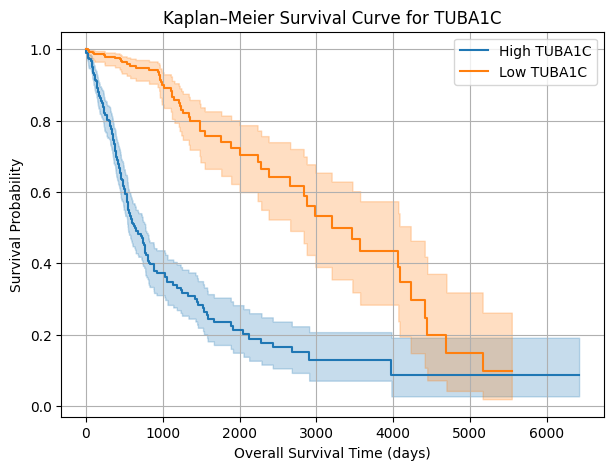

In [ ]:
# ============================================================
# Step 15b: Kaplan–Meier plot for TUBA1C
# ============================================================

from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# split by median expression
median_expr = survival_expr["TUBA1C"].median()

high_group = survival_expr[survival_expr["TUBA1C"] >= median_expr]
low_group  = survival_expr[survival_expr["TUBA1C"] < median_expr]

kmf = KaplanMeierFitter()

plt.figure(figsize=(7,5))

kmf.fit(
    durations=high_group["OS.time"],
    event_observed=high_group["OS"],
    label="High TUBA1C"
)
kmf.plot()

kmf.fit(
    durations=low_group["OS.time"],
    event_observed=low_group["OS"],
    label="Low TUBA1C"
)
kmf.plot()

plt.title("Kaplan–Meier Survival Curve for TUBA1C")
plt.xlabel("Overall Survival Time (days)")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# Step 16: Log-rank test
# ============================================================

from lifelines.statistics import logrank_test

results = logrank_test(
    high_group["OS.time"],
    low_group["OS.time"],
    event_observed_A=high_group["OS"],
    event_observed_B=low_group["OS"]
)

print("Log-rank test p-value:", results.p_value)

Log-rank test p-value: 1.6020016513667e-33


In [ ]:
# ============================================================
# Step 17: Cox proportional hazards model
# ============================================================

from lifelines import CoxPHFitter

cox_data = survival_expr[["OS.time", "OS", "TUBA1C"]].copy()

cox = CoxPHFitter()
cox.fit(cox_data, duration_col="OS.time", event_col="OS")

cox.print_summary()

<lifelines.CoxPHFitter: fitted with 659 total observations, 417 right-censored observations>
             duration col = 'OS.time'
                event col = 'OS'
      baseline estimation = breslow
   number of observations = 659
number of events observed = 242
   partial log-likelihood = -1198.15
         time fit was run = 2026-03-12 05:50:45 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
TUBA1C     0.72      2.06      0.04            0.64            0.81                1.89                2.25

           cmp to     z      p  -log2(p)
covariate                               
TUBA1C       0.00 16.39 <0.005    198.24
---
Concordance = 0.81
Partial AIC = 2398.30
log-likelihood ratio test = 279.96 on 1 df
-log2(p) of ll-ratio test = 206.35

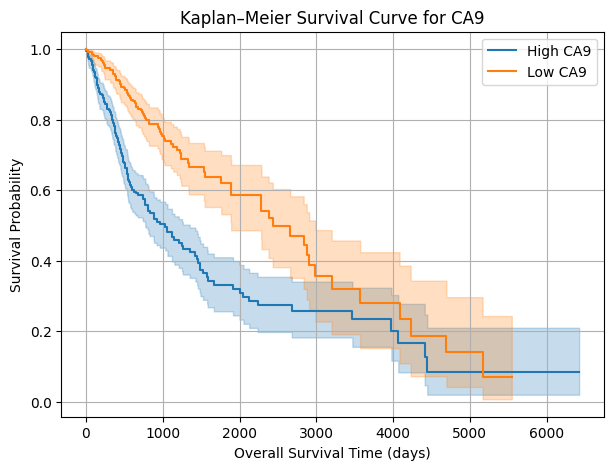

CA9 log-rank p-value: 1.98939656140599e-09


In [ ]:
# ============================================================
# Kaplan–Meier for CA9
# ============================================================

median_expr = survival_expr["CA9"].median()

high_group = survival_expr[survival_expr["CA9"] >= median_expr]
low_group  = survival_expr[survival_expr["CA9"] < median_expr]

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(7,5))

kmf.fit(high_group["OS.time"], high_group["OS"], label="High CA9")
kmf.plot()

kmf.fit(low_group["OS.time"], low_group["OS"], label="Low CA9")
kmf.plot()

plt.title("Kaplan–Meier Survival Curve for CA9")
plt.xlabel("Overall Survival Time (days)")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()

# log-rank test
result = logrank_test(
    high_group["OS.time"],
    low_group["OS.time"],
    event_observed_A=high_group["OS"],
    event_observed_B=low_group["OS"]
)

print("CA9 log-rank p-value:", result.p_value)

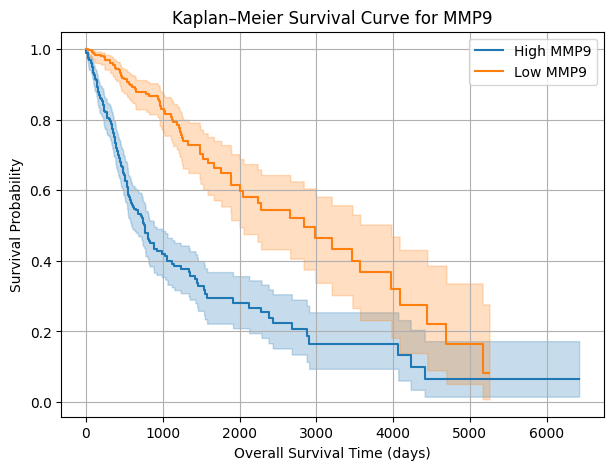

MMP9 log-rank p-value: 1.8405857217755784e-19


In [ ]:
# ============================================================
# Kaplan–Meier for MMP9
# ============================================================

median_expr = survival_expr["MMP9"].median()

high_group = survival_expr[survival_expr["MMP9"] >= median_expr]
low_group  = survival_expr[survival_expr["MMP9"] < median_expr]

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(7,5))

kmf.fit(high_group["OS.time"], high_group["OS"], label="High MMP9")
kmf.plot()

kmf.fit(low_group["OS.time"], low_group["OS"], label="Low MMP9")
kmf.plot()

plt.title("Kaplan–Meier Survival Curve for MMP9")
plt.xlabel("Overall Survival Time (days)")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()

# log-rank test
result = logrank_test(
    high_group["OS.time"],
    low_group["OS.time"],
    event_observed_A=high_group["OS"],
    event_observed_B=low_group["OS"]
)

print("MMP9 log-rank p-value:", result.p_value)

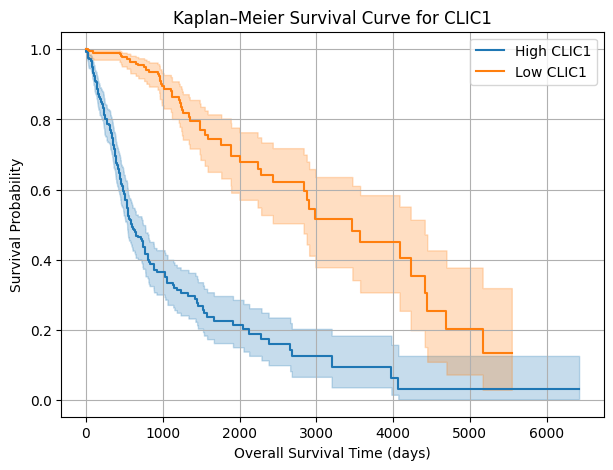

CLIC1 log-rank p-value: 5.5357335784876105e-39


In [ ]:
# ============================================================
# Kaplan–Meier for CLIC1
# ============================================================

median_expr = survival_expr["CLIC1"].median()

high_group = survival_expr[survival_expr["CLIC1"] >= median_expr]
low_group  = survival_expr[survival_expr["CLIC1"] < median_expr]

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(7,5))

kmf.fit(high_group["OS.time"], high_group["OS"], label="High CLIC1")
kmf.plot()

kmf.fit(low_group["OS.time"], low_group["OS"], label="Low CLIC1")
kmf.plot()

plt.title("Kaplan–Meier Survival Curve for CLIC1")
plt.xlabel("Overall Survival Time (days)")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()

result = logrank_test(
    high_group["OS.time"],
    low_group["OS.time"],
    event_observed_A=high_group["OS"],
    event_observed_B=low_group["OS"]
)

print("CLIC1 log-rank p-value:", result.p_value)

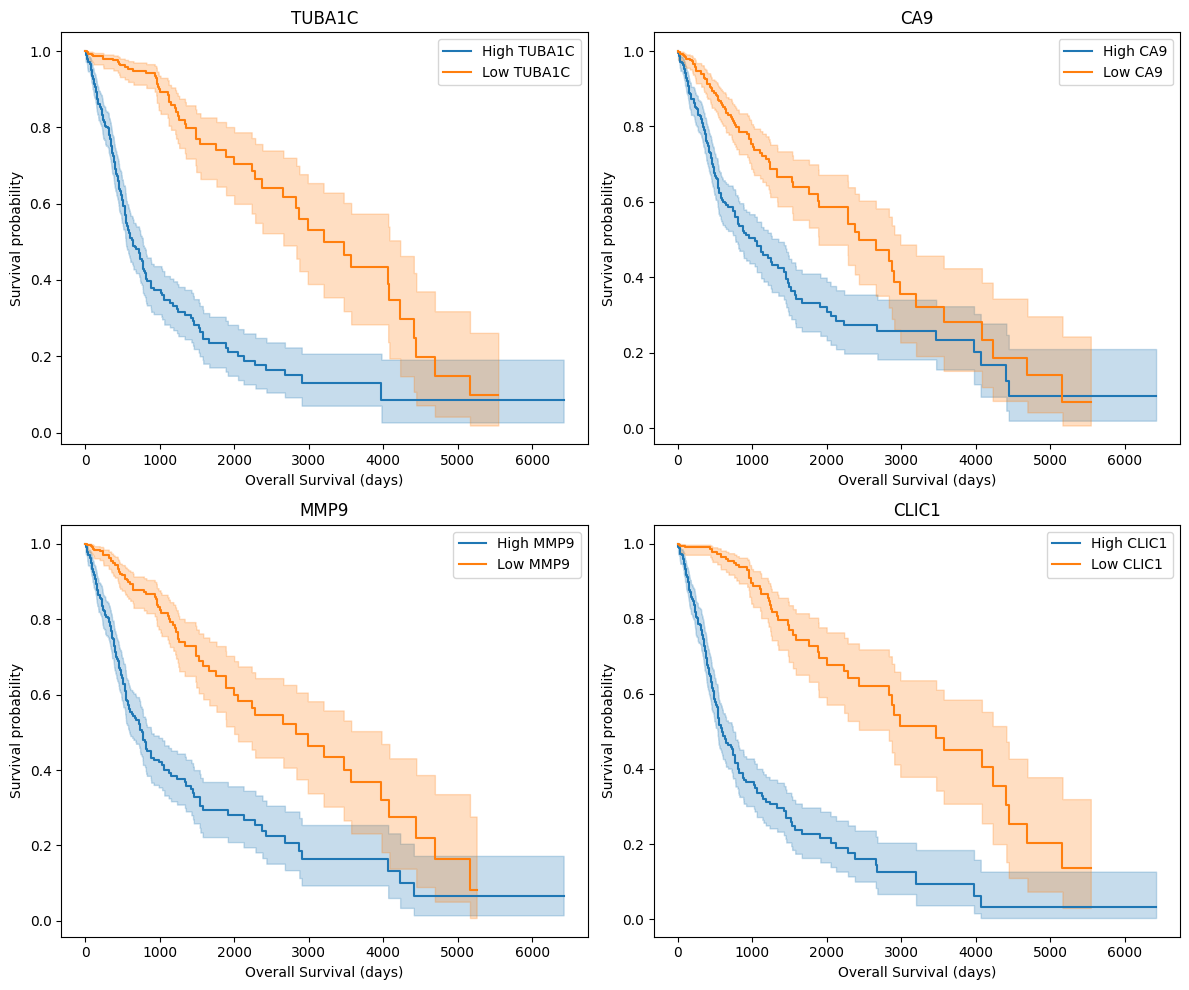

In [ ]:
# ============================================================
# Multi-panel Kaplan-Meier plot for top biomarkers
# ============================================================

genes = ["TUBA1C","CA9","MMP9","CLIC1"]

fig, axes = plt.subplots(2,2, figsize=(12,10))

from lifelines import KaplanMeierFitter

for i,gene in enumerate(genes):

    ax = axes[i//2, i%2]

    median_expr = survival_expr[gene].median()

    high = survival_expr[survival_expr[gene] >= median_expr]
    low  = survival_expr[survival_expr[gene] < median_expr]

    kmf = KaplanMeierFitter()

    kmf.fit(high["OS.time"], high["OS"], label=f"High {gene}")
    kmf.plot(ax=ax)

    kmf.fit(low["OS.time"], low["OS"], label=f"Low {gene}")
    kmf.plot(ax=ax)

    ax.set_title(gene)
    ax.set_xlabel("Overall Survival (days)")
    ax.set_ylabel("Survival probability")

plt.tight_layout()
plt.show()

Kaplan–Meier survival analysis revealed that elevated expression of TUBA1C, CA9, MMP9, and CLIC1 was significantly associated with poorer overall survival in glioma patients. Across all four biomarkers, patients in the high-expression group exhibited markedly reduced survival probabilities compared with those in the low-expression group. These results confirm that the machine learning-identified genes possess strong prognostic value in glioma.